# DATASET ANALYSIS

## Class Imbalance

### Checking for class imbalance

In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/MyDrive/Research Important Datasets/Final_Before_Image and Text.csv'
df = pd.read_csv(file_path)

# Display the first few rows (optional, for understanding)
print("First few rows of the dataset:")
print(df.head())

# Check class distribution
print("\nClass distribution in '2_way_label':")
print(df['2_way_label'].value_counts())

print("\nClass distribution (normalized):")
print(df['2_way_label'].value_counts(normalize=True))

First few rows of the dataset:
   Unnamed: 0       id                author  \
0      779462   83nd08  wonderfulworldofwill   
1      100606   1awkn4           cokacokacoh   
2      304440   4z88qq                   NaN   
3      925817   1fyz0l           stunnellweb   
4      859097  cpy1pvl            krikienoid   

                                               title             domain  \
0  'Gary Oldman costume make Winston Churchill fi...          i.redd.it   
1  'WATCH : Woman Lights Snake Fire , Snake Incin...  newsfeed.time.com   
2  ' 8 year old Chicago girl shot arm attended vi...            apne.ws   
3       'Dog wearing pirate hat sailing tortoise . '        i.imgur.com   
4                                    'Look , hands '                NaN   

   num_comments  score  upvote_ratio  polarity  emotion_score  2_way_label  \
0           1.0     21          0.83       0.0           -1.0            0   
1          10.0     23          0.83       0.0           -1.0            

## Missing Values

In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/MyDrive/Research Important Datasets/Final_Before_Image and Text.csv'
df = pd.read_csv(file_path)

# Define the columns to ignore
ignore_cols = ['id', 'author', 'domain']
last_relevant_col = 'sub_region'  # columns after this will be ignored

# Select relevant columns only
relevant_cols = df.loc[:, :last_relevant_col].drop(columns=ignore_cols)

# Check missing values
print("🔍 Missing values per relevant column:")
print(relevant_cols.isnull().sum())

print("\n📊 Percentage of missing values (relevant columns only):")
print((relevant_cols.isnull().sum() / len(df)) * 100)

🔍 Missing values per relevant column:
Unnamed: 0            0
title                 0
num_comments     203139
score                 0
upvote_ratio     203139
polarity              0
emotion_score         0
2_way_label           0
sub_region            0
dtype: int64

📊 Percentage of missing values (relevant columns only):
Unnamed: 0        0.000000
title             0.000000
num_comments     20.903246
score             0.000000
upvote_ratio     20.903246
polarity          0.000000
emotion_score     0.000000
2_way_label       0.000000
sub_region        0.000000
dtype: float64


### Handling Missing Values

In [ ]:
import pandas as pd

# Load the original dataset
file_path = '/content/drive/MyDrive/Research Important Datasets/Final_Before_Image and Text.csv'
df = pd.read_csv(file_path)

# Fill missing values
df['num_comments'] = df['num_comments'].fillna(0)
df['upvote_ratio'] = df['upvote_ratio'].fillna(df['upvote_ratio'].median())

# Save cleaned dataset to new CSV
cleaned_file_path = '/content/drive/MyDrive/Research Important Datasets/Final_Before_Image_and_Text_cleaned.csv'
df.to_csv(cleaned_file_path, index=False)

# Reload the cleaned dataset
df_cleaned = pd.read_csv(cleaned_file_path)

# Check missing values in relevant columns
missing_num_comments = df_cleaned['num_comments'].isnull().sum()
missing_upvote_ratio = df_cleaned['upvote_ratio'].isnull().sum()

print(f"Missing values in 'num_comments' after cleaning: {missing_num_comments}")
print(f"Missing values in 'upvote_ratio' after cleaning: {missing_upvote_ratio}")

Missing values in 'num_comments' after cleaning: 0
Missing values in 'upvote_ratio' after cleaning: 0


In [ ]:
import pandas as pd

# Load the dataset
file_path = '/content/drive/MyDrive/Research Important Datasets/Final_Before_Image_and_Text_cleaned.csv'
df = pd.read_csv(file_path)

# Define the columns to ignore
ignore_cols = ['id', 'author', 'domain']
last_relevant_col = 'sub_region'  # columns after this will be ignored

# Select relevant columns only
relevant_cols = df.loc[:, :last_relevant_col].drop(columns=ignore_cols)

# Check missing values
print("🔍 Missing values per relevant column:")
print(relevant_cols.isnull().sum())

print("\n📊 Percentage of missing values (relevant columns only):")
print((relevant_cols.isnull().sum() / len(df)) * 100)

🔍 Missing values per relevant column:
Unnamed: 0       0
title            0
num_comments     0
score            0
upvote_ratio     0
polarity         0
emotion_score    0
2_way_label      0
sub_region       0
dtype: int64

📊 Percentage of missing values (relevant columns only):
Unnamed: 0       0.0
title            0.0
num_comments     0.0
score            0.0
upvote_ratio     0.0
polarity         0.0
emotion_score    0.0
2_way_label      0.0
sub_region       0.0
dtype: float64


## Text-Specific Checks

### Checking Missing Titles

In [ ]:
missing_titles = df['title'].isnull().sum()
empty_titles = (df['title'].str.strip() == '').sum()
print(f"Missing titles: {missing_titles}")
print(f"Empty titles: {empty_titles}")

Missing titles: 0
Empty titles: 0


### Text Length Distribution

In [ ]:
df['title_char_len'] = df['title'].str.len()
df['title_word_count'] = df['title'].str.split().apply(len)

print(df['title_char_len'].describe())
print(df['title_word_count'].describe())

count    971806.000000
mean         43.934920
std          27.820951
min           2.000000
25%          24.000000
50%          39.000000
75%          58.000000
max        1857.000000
Name: title_char_len, dtype: float64
count    971806.000000
mean          7.939452
std           4.557322
min           1.000000
25%           5.000000
50%           7.000000
75%          10.000000
max         352.000000
Name: title_word_count, dtype: float64


### Check for duplicates

In [ ]:
duplicate_titles = df['title'].duplicated().sum()
print(f"Number of duplicate titles: {duplicate_titles}")

Number of duplicate titles: 88222


### Handling Duplicates

In [ ]:
import pandas as pd

# Load dataset
file_path = '/content/drive/MyDrive/Research Important Datasets/Final_Before_Image_and_Text_cleaned.csv'
df = pd.read_csv(file_path)

# Add duplicate count feature
df['title_dup_count'] = df.groupby('title')['title'].transform('count')

# Check class distribution in duplicated titles (for your understanding, optional)
duplicated_titles = df[df.duplicated(subset='title', keep=False)]
print("⚖️ Class distribution among duplicated titles:")
print(duplicated_titles['2_way_label'].value_counts(normalize=True))

# Save cleaned, enriched dataset for modeling
output_path = '/content/drive/MyDrive/Research Important Datasets/final_dataset_with_dupcount.csv'
df.to_csv(output_path, index=False)
print("✅ Cleaned and enriched dataset saved!")

⚖️ Class distribution among duplicated titles:
2_way_label
0    0.678559
1    0.321441
Name: proportion, dtype: float64
✅ Cleaned and enriched dataset saved!


### Check for encoding issues

In [ ]:
non_ascii = df['title'].apply(lambda x: any(ord(c) > 127 for c in str(x)))
print(f"Titles with non-ASCII chars: {non_ascii.sum()}")

Titles with non-ASCII chars: 0


### Basic Text Cleaning Preview

In [ ]:
import string
sample_title = df['title'].iloc[0]
cleaned = sample_title.lower().translate(str.maketrans('', '', string.punctuation)).strip()
print("Original:", sample_title)
print("Cleaned:", cleaned)

Original: 'Gary Oldman costume make Winston Churchill film Darkest Hour ( 2017 ) '
Cleaned: gary oldman costume make winston churchill film darkest hour  2017


### Word Frequency and Common Tokens

In [ ]:
from collections import Counter
from nltk.corpus import stopwords
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))
words = df['title'].str.lower().str.cat(sep=' ').split()
words = [w for w in words if w.isalpha() and w not in stop_words]
common_words = Counter(words).most_common(20)
print(common_words)

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


[('like', 27733), ('man', 24883), ('new', 17369), ('dog', 17042), ('looks', 16131), ('one', 16018), ('cat', 14917), ('old', 14358), ('found', 14146), ('r', 12224), ('first', 11931), ('year', 11810), ('colorized', 11605), ('post', 10723), ('trump', 10579), ('guy', 10551), ('time', 10085), ('says', 9865), ('people', 9641), ('way', 9523)]


## Exploratory Data Analysis

### Target Variable Analysis

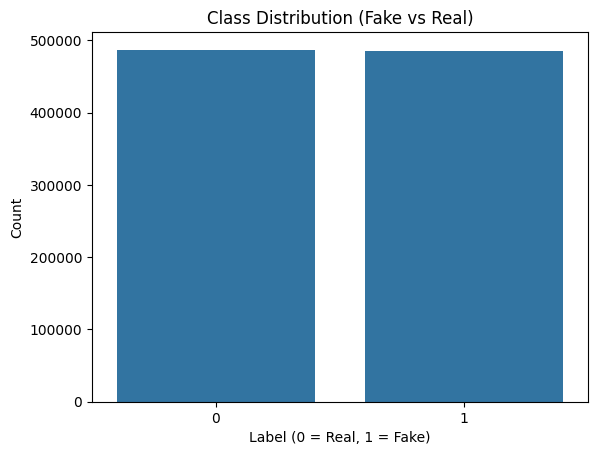

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='2_way_label', data=df)
plt.title("Class Distribution (Fake vs Real)")
plt.xlabel("Label (0 = Real, 1 = Fake)")
plt.ylabel("Count")
plt.show()

### Numerical Feature Distributions

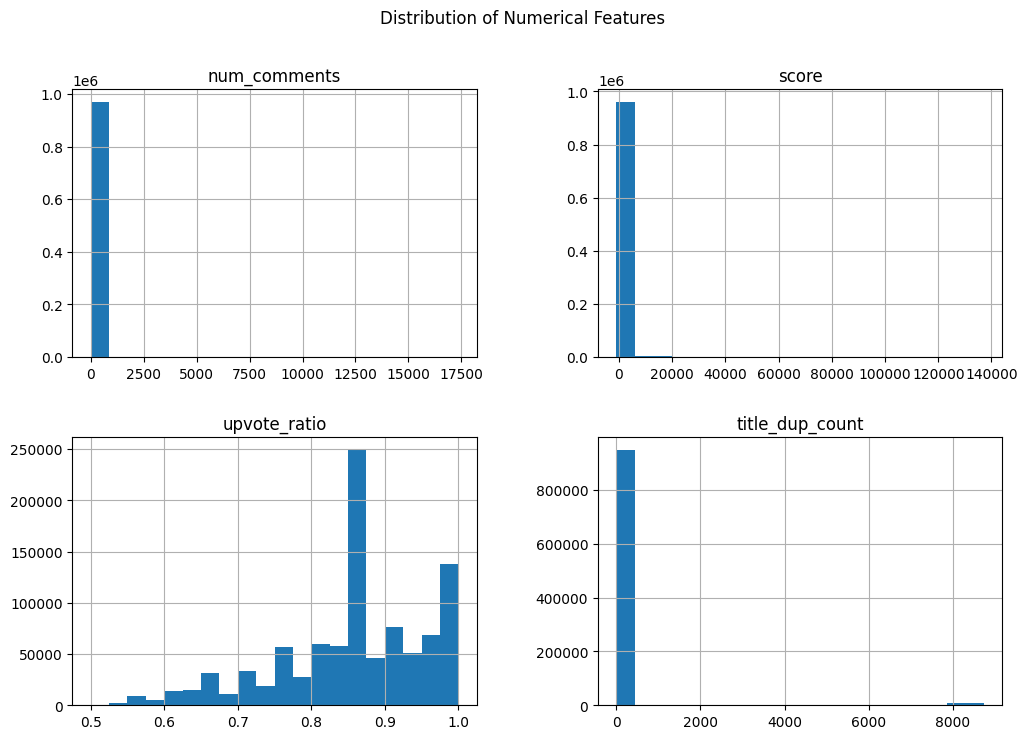

In [ ]:
num_cols = ['num_comments', 'score', 'upvote_ratio', 'title_dup_count']
df[num_cols].describe()

# Histograms
df[num_cols].hist(bins=20, figsize=(12, 8))
plt.suptitle("Distribution of Numerical Features")
plt.show()

### Feature Relationships with Target

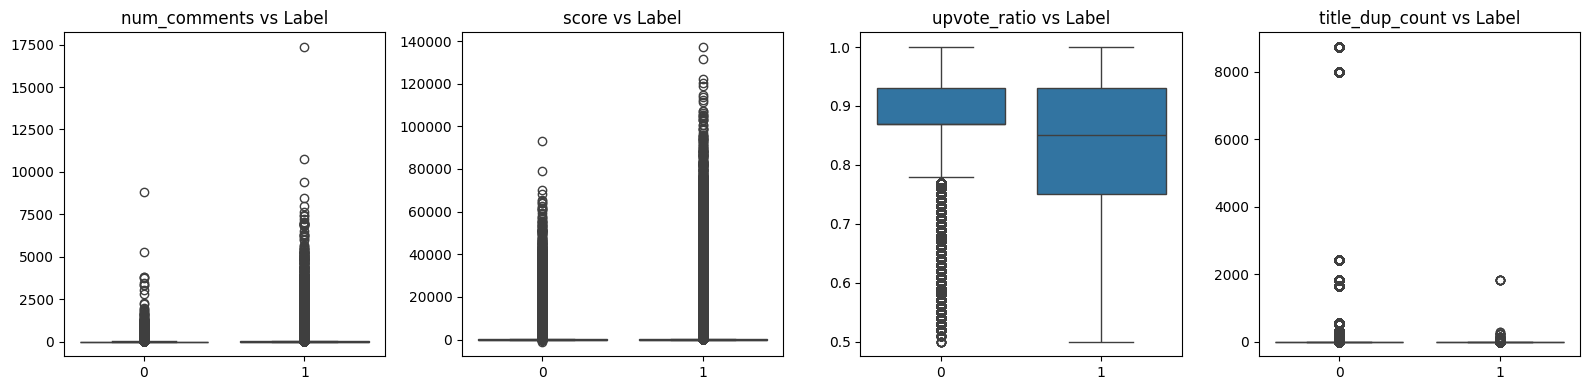

📊 Outlier summary based on IQR (per class):

Feature: num_comments
  Label 0: 69616 outliers (14.29%)
  Label 1: 54147 outliers (11.17%)

Feature: score
  Label 0: 71375 outliers (14.65%)
  Label 1: 70126 outliers (14.47%)

Feature: upvote_ratio
  Label 0: 49362 outliers (10.13%)
  Label 1: 0 outliers (0.00%)

Feature: title_dup_count
  Label 0: 81915 outliers (16.82%)
  Label 1: 38804 outliers (8.01%)



In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['num_comments', 'score', 'upvote_ratio', 'title_dup_count']

plt.figure(figsize=(16, 4))  # Adjust width/height based on number of plots

for i, col in enumerate(num_cols, 1):
    plt.subplot(1, len(num_cols), i)
    sns.boxplot(x='2_way_label', y=col, data=df)
    plt.title(f"{col} vs Label")
    plt.xlabel('')  # Optional: Remove x-label for cleaner look
    plt.ylabel('')

plt.tight_layout()
plt.show()

print("📊 Outlier summary based on IQR (per class):\n")

for col in num_cols:
    print(f"Feature: {col}")
    for label in df['2_way_label'].unique():
        data = df[df['2_way_label'] == label][col]
        Q1 = data.quantile(0.25)
        Q3 = data.quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        outliers = data[(data < lower_bound) | (data > upper_bound)]
        outlier_pct = len(outliers) / len(data) * 100
        print(f"  Label {label}: {len(outliers)} outliers ({outlier_pct:.2f}%)")
    print()

### Text Feature Exploration (Title)

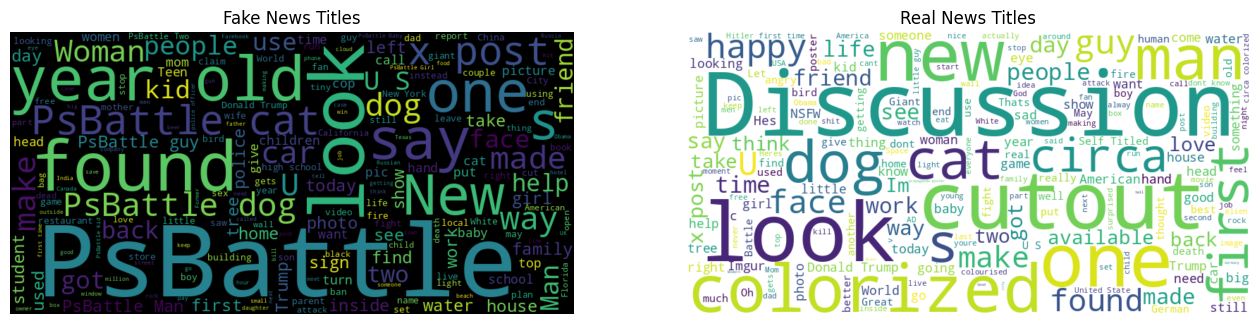

In [ ]:
from wordcloud import WordCloud

fake_titles = ' '.join(df[df['2_way_label'] == 1]['title'].dropna().tolist())
real_titles = ' '.join(df[df['2_way_label'] == 0]['title'].dropna().tolist())

wordcloud_fake = WordCloud(width=800, height=400, background_color='black').generate(fake_titles)
wordcloud_real = WordCloud(width=800, height=400, background_color='white').generate(real_titles)

plt.figure(figsize=(16, 8))
plt.subplot(1, 2, 1)
plt.imshow(wordcloud_fake, interpolation='bilinear')
plt.title("Fake News Titles")
plt.axis('off')

plt.subplot(1, 2, 2)
plt.imshow(wordcloud_real, interpolation='bilinear')
plt.title("Real News Titles")
plt.axis('off')
plt.show()

### Correlation Matrix

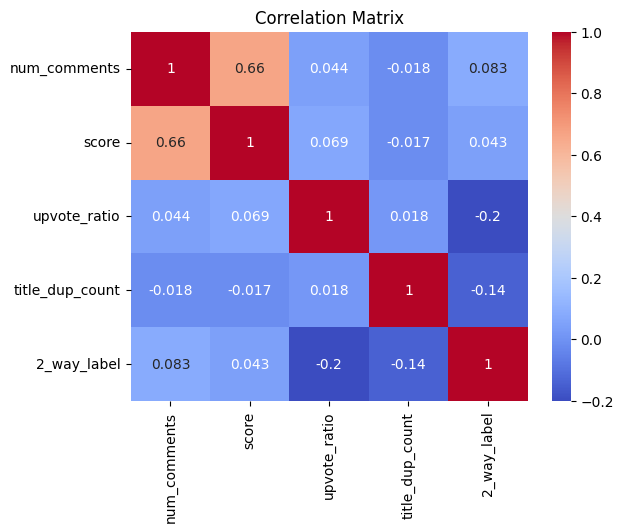

In [ ]:
import numpy as np

correlation = df[num_cols + ['2_way_label']].corr()
sns.heatmap(correlation, annot=True, cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

### Sub-region Analysis (if meaningful)

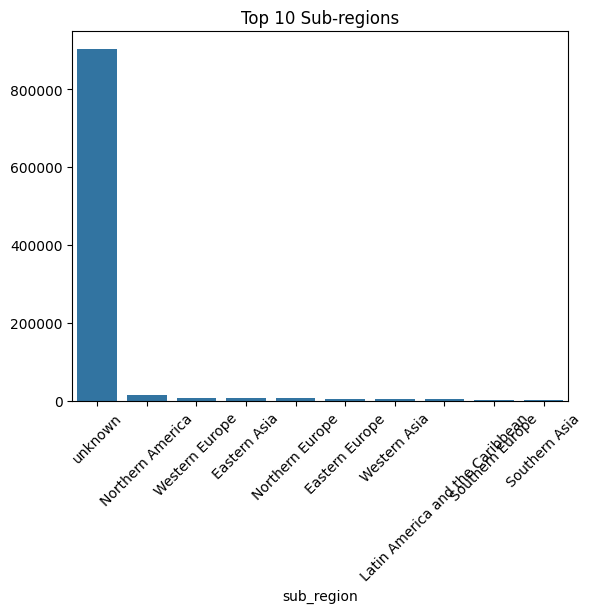

In [ ]:
sub_region_counts = df['sub_region'].value_counts().head(10)
sns.barplot(x=sub_region_counts.index, y=sub_region_counts.values)
plt.title("Top 10 Sub-regions")
plt.xticks(rotation=45)
plt.show()

## Label Encoding or Transformation

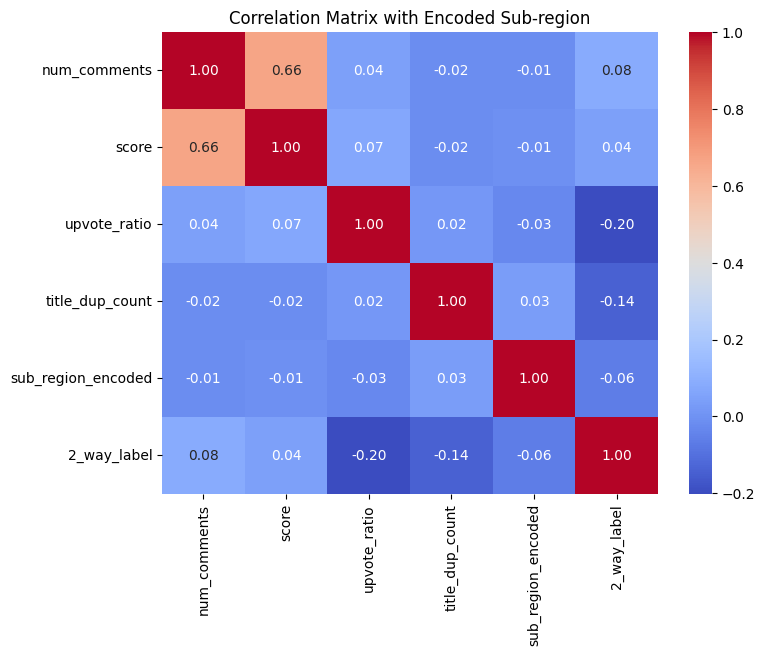

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder

# Load dataset
file_path = '/content/drive/MyDrive/Research Important Datasets/final_dataset_with_dupcount.csv'
df = pd.read_csv(file_path)

# Fill missing values for safety (if needed)
df['num_comments'] = df['num_comments'].fillna(0)
df['upvote_ratio'] = df['upvote_ratio'].fillna(df['upvote_ratio'].median())
df['sub_region'] = df['sub_region'].fillna('unknown')  # If any missing

# Label encode 'sub_region'
le = LabelEncoder()
df['sub_region_encoded'] = le.fit_transform(df['sub_region'])

# Select numeric columns for correlation including encoded sub_region
corr_cols = ['num_comments', 'score', 'upvote_ratio', 'title_dup_count', 'sub_region_encoded', '2_way_label']

# Compute correlation matrix
corr_matrix = df[corr_cols].corr()

# Plot heatmap
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix with Encoded Sub-region")
plt.show()